# Dataset Overview

Tahap ini bertujuan untuk melakukan eksplorasi awal terhadap dataset yang digunakan pada penelitian. Pemeriksaan dilakukan untuk mengetahui jumlah citra pada setiap kelas serta memastikan distribusi data telah sesuai sebelum dilakukan preprocessing dan pelatihan model klasifikasi.

In [50]:
from pathlib import Path

DATASET_PATH = Path(
    "/content/drive/MyDrive/Dataset ML/Dataset Slingbag & Totebag"
)

classes = ["Slingbag", "Totebag"]

for class_name in classes:

    total = len(
        list(
            (DATASET_PATH / class_name).glob("*")
        )
    )

    print(
        f"{class_name}: {total}"
    )

Slingbag: 500
Totebag: 500


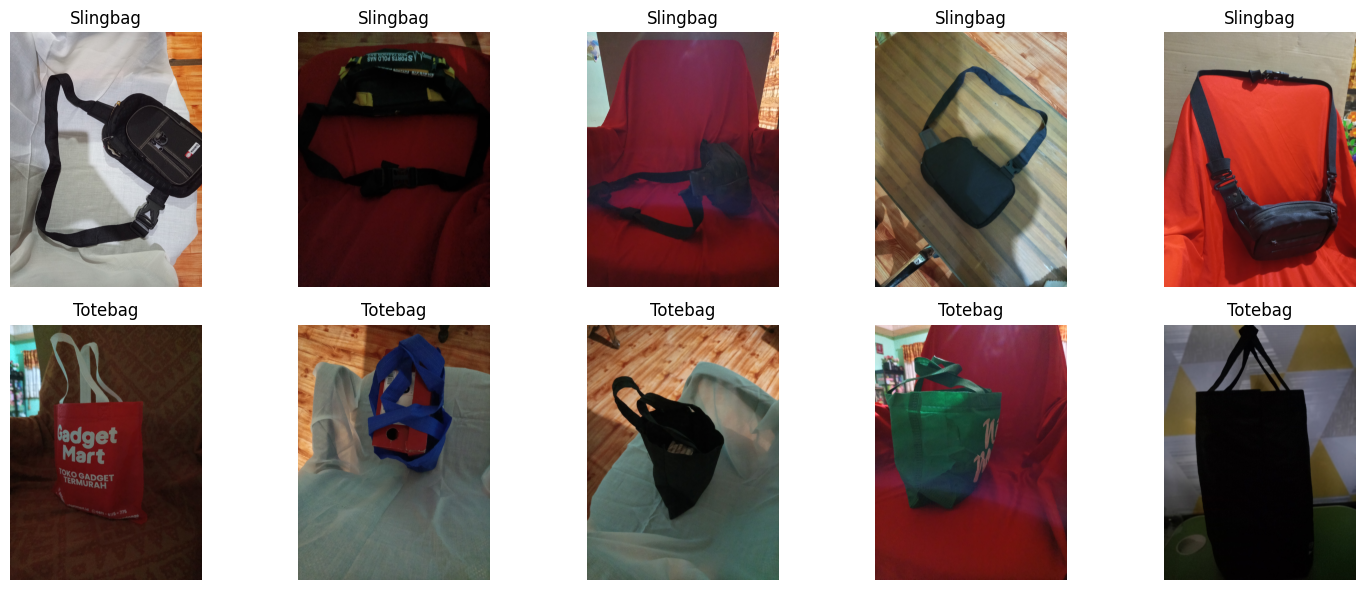

In [51]:
import random
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(15,6))

for i, class_name in enumerate(classes):

    images = list(
        (DATASET_PATH / class_name).glob("*")
    )

    samples = random.sample(images, 5)

    for j, img_path in enumerate(samples):

        plt.subplot(
            2,
            5,
            i * 5 + j + 1
        )

        img = Image.open(img_path)

        plt.imshow(img)
        plt.title(class_name)

        plt.axis("off")

plt.tight_layout()
plt.show()

# Data Preprocessing

Notebook ini berisi tahapan preprocessing dataset yang meliputi penyeragaman ukuran citra menjadi 256×256 piksel dan pengorganisasian data agar siap digunakan pada proses pelatihan model. Tahap preprocessing dilakukan untuk meningkatkan konsistensi data masukan sehingga proses ekstraksi fitur dan pembelajaran model dapat berjalan lebih optimal.

In [52]:
from pathlib import Path
from PIL import Image
from tqdm import tqdm

In [53]:
DATASET_PATH = Path(
    "/content/drive/MyDrive/Dataset ML/Dataset Slingbag & Totebag"
)

OUTPUT_PATH = Path(
    "/content/drive/MyDrive/Dataset ML/Dataset_256_Preprocessing"
)

OUTPUT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print(OUTPUT_PATH)

/content/drive/MyDrive/Dataset ML/Dataset_256_Preprocessing


In [54]:
classes = [
    "Slingbag",
    "Totebag"
]

for class_name in classes:

    (
        OUTPUT_PATH /
        class_name
    ).mkdir(
        parents=True,
        exist_ok=True
    )

print("Folder berhasil dibuat")

Folder berhasil dibuat


In [55]:
IMG_SIZE = (256, 256)

for class_name in classes:

    source_folder = (
        DATASET_PATH /
        class_name
    )

    target_folder = (
        OUTPUT_PATH /
        class_name
    )

    images = list(
        source_folder.glob("*")
    )

    print(
        f"\nProcessing {class_name}: {len(images)} gambar"
    )

    for image_path in tqdm(images):

        try:

            img = Image.open(
                image_path
            ).convert("RGB")

            img = img.resize(
                IMG_SIZE
            )

            img.save(
                target_folder /
                image_path.name
            )

        except Exception as e:

            print(
                f"Gagal: {image_path.name}"
            )

print("\nPreprocessing selesai")


Processing Slingbag: 500 gambar


100%|██████████| 500/500 [02:13<00:00,  3.75it/s]



Processing Totebag: 500 gambar


100%|██████████| 500/500 [02:15<00:00,  3.70it/s]


Preprocessing selesai


In [56]:
for class_name in classes:

    total = len(
        list(
            (
                OUTPUT_PATH /
                class_name
            ).glob("*")
        )
    )

    print(
        f"{class_name}: {total}"
    )

Slingbag: 500
Totebag: 500


# Data Splitting

Notebook ini bertujuan untuk membagi dataset ke dalam data training, validation, dan testing menggunakan rasio 70:15:15. Pembagian dilakukan secara terstruktur untuk mendukung proses pelatihan, validasi, dan evaluasi model secara objektif serta menghindari terjadinya data leakage antar subset data.

In [57]:
from pathlib import Path
import shutil
import random

from sklearn.model_selection import train_test_split

In [58]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)

print("Random Seed:", RANDOM_STATE)

Random Seed: 42


In [59]:
DATASET_PATH = Path(
    "/content/drive/MyDrive/Dataset ML/Dataset_256_Preprocessing"
)

SPLIT_PATH = Path(
    "/content/drive/MyDrive/Dataset ML/Dataset_Split_UAS"
)

SPLIT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print(SPLIT_PATH)

/content/drive/MyDrive/Dataset ML/Dataset_Split_UAS


In [60]:
classes = [
    "Slingbag",
    "Totebag"
]

for split in [
    "train",
    "validation",
    "test"
]:

    for class_name in classes:

        (
            SPLIT_PATH /
            split /
            class_name
        ).mkdir(
            parents=True,
            exist_ok=True
        )

print("Struktur folder berhasil dibuat")

Struktur folder berhasil dibuat


In [61]:
for class_name in classes:

    folder = (
        DATASET_PATH /
        class_name
    )

    images = list(
        folder.glob("*.jpg")
    )

    train_images, temp_images = train_test_split(
        images,
        test_size=0.30,
        random_state=RANDOM_STATE
    )

    validation_images, test_images = train_test_split(
        temp_images,
        test_size=0.50,
        random_state=RANDOM_STATE
    )

    print(f"\n{class_name}")
    print(f"Train      : {len(train_images)}")
    print(f"Validation : {len(validation_images)}")
    print(f"Test       : {len(test_images)}")


Slingbag
Train      : 350
Validation : 75
Test       : 75

Totebag
Train      : 350
Validation : 75
Test       : 75


In [62]:
for class_name in classes:

    folder = (
        DATASET_PATH /
        class_name
    )

    images = list(
        folder.glob("*.jpg")
    )

    train_images, temp_images = train_test_split(
        images,
        test_size=0.30,
        random_state=RANDOM_STATE
    )

    validation_images, test_images = train_test_split(
        temp_images,
        test_size=0.50,
        random_state=RANDOM_STATE
    )

    for image_path in train_images:

        shutil.copy(
            image_path,
            SPLIT_PATH /
            "train" /
            class_name /
            image_path.name
        )

    for image_path in validation_images:

        shutil.copy(
            image_path,
            SPLIT_PATH /
            "validation" /
            class_name /
            image_path.name
        )

    for image_path in test_images:

        shutil.copy(
            image_path,
            SPLIT_PATH /
            "test" /
            class_name /
            image_path.name
        )

print("Proses split selesai")

Proses split selesai


In [63]:
for split in [
    "train",
    "validation",
    "test"
]:

    print(f"\n=== {split.upper()} ===")

    total = 0

    for class_name in classes:

        count = len(
            list(
                (
                    SPLIT_PATH /
                    split /
                    class_name
                ).glob("*.jpg")
            )
        )

        total += count

        print(
            f"{class_name}: {count}"
        )

    print(
        f"Total: {total}"
    )


=== TRAIN ===
Slingbag: 350
Totebag: 350
Total: 700

=== VALIDATION ===
Slingbag: 75
Totebag: 75
Total: 150

=== TEST ===
Slingbag: 75
Totebag: 75
Total: 150


In [64]:
train_files = set(
    str(p.relative_to(SPLIT_PATH / "train"))
    for p in (SPLIT_PATH / "train").rglob("*.jpg")
)

validation_files = set(
    str(p.relative_to(SPLIT_PATH / "validation"))
    for p in (SPLIT_PATH / "validation").rglob("*.jpg")
)

test_files = set(
    str(p.relative_to(SPLIT_PATH / "test"))
    for p in (SPLIT_PATH / "test").rglob("*.jpg")
)

print(
    "Train-Test:",
    len(train_files & test_files)
)

print(
    "Train-Validation:",
    len(train_files & validation_files)
)

print(
    "Validation-Test:",
    len(validation_files & test_files)
)

Train-Test: 0
Train-Validation: 0
Validation-Test: 0


# HOG + SVM Classification

Notebook ini berisi implementasi metode Machine Learning menggunakan Histogram of Oriented Gradients (HOG) sebagai teknik ekstraksi fitur dan Support Vector Machine (SVM) sebagai algoritma klasifikasi. Beberapa kernel SVM diuji untuk memperoleh performa terbaik dalam membedakan citra Slingbag dan Totebag.

In [85]:
import os
import cv2
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

In [86]:
RANDOM_STATE = 42

IMG_SIZE = 256

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

CLASSES = [
    "Slingbag",
    "Totebag"
]

In [87]:
DATASET_PATH = Path(
    "/content/drive/MyDrive/Dataset ML/Dataset_Split_UAS"
)

TRAIN_PATH = DATASET_PATH / "train"

VALIDATION_PATH = DATASET_PATH / "validation"

TEST_PATH = DATASET_PATH / "test"

In [88]:
# Cell 4

def flip_horizontal(img):
    return cv2.flip(img, 1)


def rotate(img, angle_range=(-15, 15)):

    angle = random.uniform(*angle_range)

    h, w = img.shape[:2]

    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    return cv2.warpAffine(
        img,
        M,
        (w, h),
        borderMode=cv2.BORDER_REFLECT
    )


def adjust_brightness(
    img,
    factor_range=(0.6, 1.4)
):

    factor = random.uniform(*factor_range)

    return np.clip(
        img.astype(np.float32) * factor,
        0,
        255
    ).astype(np.uint8)


def add_gaussian_noise(
    img,
    std_range=(5, 20)
):

    std = random.uniform(*std_range)

    noise = np.random.normal(
        0,
        std,
        img.shape
    ).astype(np.float32)

    return np.clip(
        img.astype(np.float32) + noise,
        0,
        255
    ).astype(np.uint8)


def flip_and_rotate(img):

    return rotate(
        flip_horizontal(img)
    )


def brightness_and_noise(img):

    return add_gaussian_noise(
        adjust_brightness(img)
    )

In [89]:
AUGMENT_FUNCS = [
    flip_horizontal,
    rotate,
    adjust_brightness,
    add_gaussian_noise,
    flip_and_rotate,
    brightness_and_noise
]

In [90]:
def extract_hog(img):

    return hog(
        img,
        orientations=9,
        pixels_per_cell=(64, 64),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        channel_axis=-1
    )

In [91]:
def load_images(folder_path, class_idx):

    images = []
    labels = []

    image_files = list(
        folder_path.glob("*.jpg")
    )

    for image_path in image_files:

        img = cv2.imread(
            str(image_path)
        )

        if img is None:
            continue

        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE)
        )

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        images.append(img)

        labels.append(class_idx)

    return images, labels

In [92]:
X_train_img = []
y_train = []

for class_idx, class_name in enumerate(CLASSES):

    train_folder = (
        TRAIN_PATH /
        class_name
    )

    val_folder = (
        VALIDATION_PATH /
        class_name
    )

    imgs1, lbls1 = load_images(
        train_folder,
        class_idx
    )

    imgs2, lbls2 = load_images(
        val_folder,
        class_idx
    )

    X_train_img.extend(imgs1)
    X_train_img.extend(imgs2)

    y_train.extend(lbls1)
    y_train.extend(lbls2)

print(
    "Training Images:",
    len(X_train_img)
)

Training Images: 850


In [93]:
X_test_img = []
y_test = []

for class_idx, class_name in enumerate(CLASSES):

    test_folder = (
        TEST_PATH /
        class_name
    )

    imgs, lbls = load_images(
        test_folder,
        class_idx
    )

    X_test_img.extend(imgs)

    y_test.extend(lbls)

print(
    "Test Images:",
    len(X_test_img)
)

Test Images: 150


In [94]:
def augment_train(
    images,
    labels,
    target_multiplier=2
):

    X_aug = list(images)
    y_aug = list(labels)

    unique_classes = np.unique(labels)

    for cls in unique_classes:

        cls_idx = [
            i
            for i, lbl in enumerate(labels)
            if lbl == cls
        ]

        target_count = (
            len(cls_idx)
            * target_multiplier
        )

        current_count = len(cls_idx)

        needed = (
            target_count
            - current_count
        )

        counter = 0

        while counter < needed:

            source_img = images[
                random.choice(cls_idx)
            ]

            func = AUGMENT_FUNCS[
                counter %
                len(AUGMENT_FUNCS)
            ]

            aug_img = func(source_img)

            X_aug.append(
                aug_img
            )

            y_aug.append(
                cls
            )

            counter += 1

    return X_aug, y_aug

In [95]:
X_train_img_aug, y_train_aug = augment_train(
    X_train_img,
    y_train,
    target_multiplier=2
)

print(
    "Training Original:",
    len(X_train_img)
)

print(
    "Training After Augmentation:",
    len(X_train_img_aug)
)

Training Original: 850
Training After Augmentation: 1700


In [96]:
X_train_hog = [
    extract_hog(img)
    for img in X_train_img_aug
]

X_test_hog = [
    extract_hog(img)
    for img in X_test_img
]

X_train_hog = np.array(
    X_train_hog
)

X_test_hog = np.array(
    X_test_hog
)

print(
    "Train HOG Shape:",
    X_train_hog.shape
)

print(
    "Test HOG Shape:",
    X_test_hog.shape
)

Train HOG Shape: (1700, 324)
Test HOG Shape: (150, 324)


In [97]:
scaler = StandardScaler()

X_train_hog = scaler.fit_transform(
    X_train_hog
)

X_test_hog = scaler.transform(
    X_test_hog
)

In [98]:
print(
    "Train Samples:",
    len(X_train_hog)
)

print(
    "Test Samples:",
    len(X_test_hog)
)

Train Samples: 1700
Test Samples: 150


In [99]:
svm_rbf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=RANDOM_STATE
)

svm_rbf.fit(
    X_train_hog,
    y_train_aug
)

y_pred_rbf = svm_rbf.predict(
    X_test_hog
)

acc_rbf = accuracy_score(
    y_test,
    y_pred_rbf
)

print(
    "Accuracy:",
    round(acc_rbf * 100, 2),
    "%"
)

print(
    classification_report(
        y_test,
        y_pred_rbf,
        target_names=CLASSES
    )
)

Accuracy: 97.33 %
              precision    recall  f1-score   support

    Slingbag       0.96      0.99      0.97        75
     Totebag       0.99      0.96      0.97        75

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



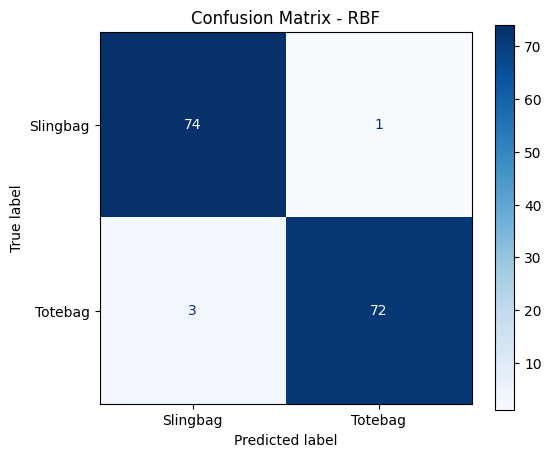

In [100]:
cm_rbf = confusion_matrix(
    y_test,
    y_pred_rbf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rbf,
    display_labels=CLASSES
)

fig, ax = plt.subplots(
    figsize=(6,5)
)

disp.plot(
    cmap="Blues",
    ax=ax
)

plt.title(
    "Confusion Matrix - RBF"
)

plt.show()

In [101]:
svm_poly = SVC(
    kernel="poly",
    degree=3,
    C=1.0,
    gamma="scale",
    random_state=RANDOM_STATE
)

svm_poly.fit(
    X_train_hog,
    y_train_aug
)

y_pred_poly = svm_poly.predict(
    X_test_hog
)

acc_poly = accuracy_score(
    y_test,
    y_pred_poly
)

print(
    "Accuracy:",
    round(acc_poly * 100, 2),
    "%"
)

print(
    classification_report(
        y_test,
        y_pred_poly,
        target_names=CLASSES
    )
)

Accuracy: 94.67 %
              precision    recall  f1-score   support

    Slingbag       0.97      0.92      0.95        75
     Totebag       0.92      0.97      0.95        75

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



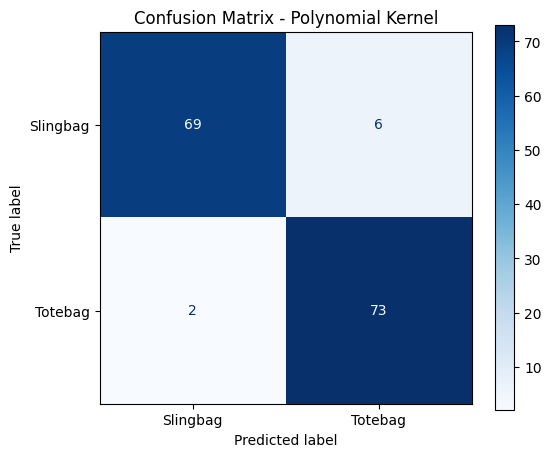

In [103]:
cm_poly = confusion_matrix(
    y_test,
    y_pred_poly
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_poly,
    display_labels=CLASSES
)

fig, ax = plt.subplots(
    figsize=(6,5)
)

disp.plot(
    cmap="Blues",
    ax=ax
)

plt.title(
    "Confusion Matrix - Polynomial Kernel"
)

plt.show()

In [106]:
svm_linear = SVC(
    kernel="linear",
    C=1.0,
    random_state=RANDOM_STATE
)

svm_linear.fit(
    X_train_hog,
    y_train_aug
)

y_pred_linear = svm_linear.predict(
    X_test_hog
)

acc_linear = accuracy_score(
    y_test,
    y_pred_linear
)

print(
    "Accuracy:",
    round(acc_linear * 100, 2),
    "%"
)

print(
    classification_report(
        y_test,
        y_pred_linear,
        target_names=CLASSES
    )
)

Accuracy: 86.67 %
              precision    recall  f1-score   support

    Slingbag       0.84      0.91      0.87        75
     Totebag       0.90      0.83      0.86        75

    accuracy                           0.87       150
   macro avg       0.87      0.87      0.87       150
weighted avg       0.87      0.87      0.87       150



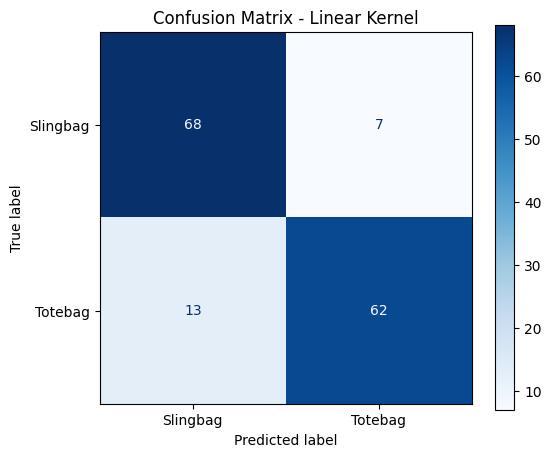

In [107]:
cm_linear = confusion_matrix(
    y_test,
    y_pred_linear
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_linear,
    display_labels=CLASSES
)

fig, ax = plt.subplots(
    figsize=(6,5)
)

disp.plot(
    cmap="Blues",
    ax=ax
)

plt.title(
    "Confusion Matrix - Linear Kernel"
)

plt.show()

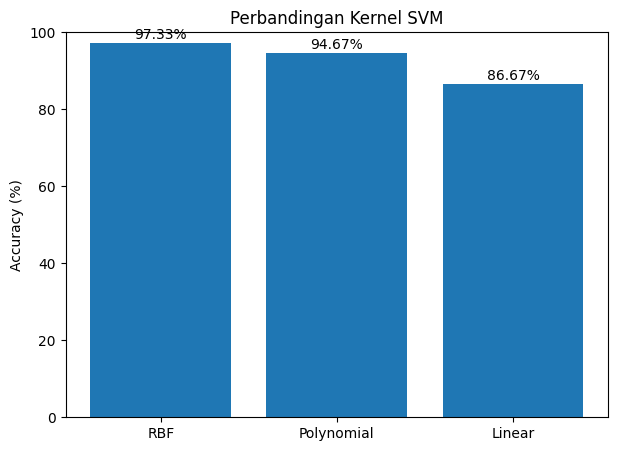

In [108]:
results = {
    "RBF": acc_rbf * 100,
    "Polynomial": acc_poly * 100,
    "Linear": acc_linear * 100
}

plt.figure(figsize=(7,5))

plt.bar(
    results.keys(),
    results.values()
)

plt.ylabel("Accuracy (%)")

plt.title(
    "Perbandingan Kernel SVM"
)

plt.ylim(0,100)

for i, v in enumerate(
    results.values()
):
    plt.text(
        i,
        v + 1,
        f"{v:.2f}%",
        ha="center"
    )

plt.show()

# MobileNetV2 Transfer Learning

Notebook ini berisi implementasi model Deep Learning berbasis Transfer Learning menggunakan arsitektur MobileNetV2. Model dilatih menggunakan bobot awal dari ImageNet dan digunakan untuk melakukan klasifikasi citra Slingbag dan Totebag. Evaluasi dilakukan menggunakan data validation dan test untuk mengukur performa model secara menyeluruh.

In [65]:
import tensorflow as tf

from pathlib import Path

from tensorflow.keras import layers
from tensorflow.keras import models

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

print(tf.__version__)

2.20.0


In [66]:
DATASET_PATH = Path(
    "/content/drive/MyDrive/Dataset ML/Dataset_Split_UAS"
)

TRAIN_PATH = DATASET_PATH / "train"

VALIDATION_PATH = DATASET_PATH / "validation"

TEST_PATH = DATASET_PATH / "test"

In [67]:
IMG_SIZE = (256, 256)

BATCH_SIZE = 32

EPOCHS = 50

In [68]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 700 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
Found 150 files belonging to 2 classes.


In [69]:
class_names = train_dataset.class_names

print(class_names)

['Slingbag', 'Totebag']


In [70]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.1
    ),

    layers.RandomZoom(
        0.1
    )

])

In [71]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

val_dataset = val_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

In [72]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(256,256,3)
)

base_model.trainable = False

/tmp/ipykernel_1405/586776189.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [73]:
inputs = tf.keras.Input(
    shape=(256,256,3)
)

x = data_augmentation(
    inputs
)

x = tf.keras.applications.mobilenet_v2.preprocess_input(
    x
)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(
    x
)

x = layers.Dropout(
    0.5
)(
    x
)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(
    x
)

model_mobilenet = tf.keras.Model(
    inputs,
    outputs
)

In [74]:
model_mobilenet.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [75]:
model_mobilenet.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [76]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [77]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Dataset ML/mobilenetv2_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [78]:
history = model_mobilenet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[
        early_stopping,
        checkpoint
    ]
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5753 - loss: 0.7262
Epoch 1: val_loss improved from None to 0.35869, saving model to /content/drive/MyDrive/Dataset ML/mobilenetv2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dataset ML/mobilenetv2_best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.6686 - loss: 0.6094 - val_accuracy: 0.9067 - val_loss: 0.3587
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8120 - loss: 0.3998
Epoch 2: val_loss improved from 0.35869 to 0.22997, saving model to /content/drive/MyDrive/Dataset ML/mobilenetv2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Dataset ML/mobilenetv2_best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.8557 - loss: 0.3441 - val_accuracy: 0.9533 - val_loss: 0.2300
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8804 - loss: 0.2858
Epoch 3: val_loss improved from 0.22997 to 0.18674, saving model to /content/drive/MyDrive

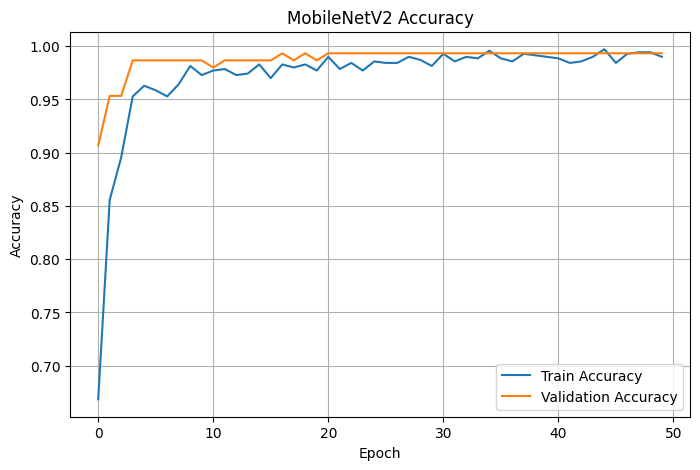

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

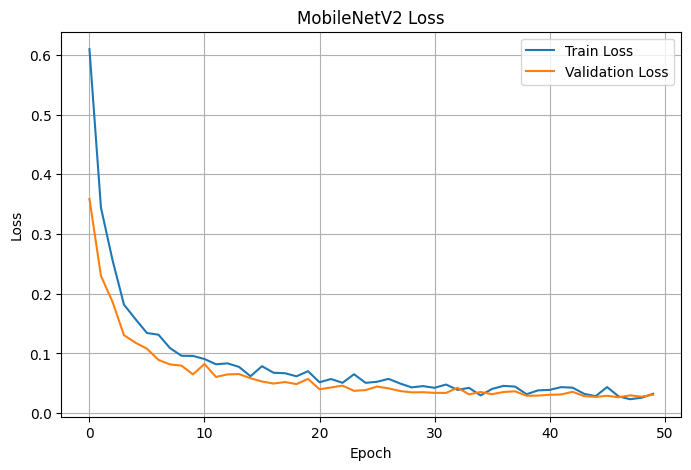

In [80]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

**Evaluasi MobileNetV2**

In [81]:
model_mobilenet = tf.keras.models.load_model(
    "/content/drive/MyDrive/Dataset ML/mobilenetv2_best.keras"
)

In [82]:
test_loss, test_accuracy = model_mobilenet.evaluate(
    test_dataset
)

print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 1.0000 - loss: 0.0162
Test Accuracy: 1.0


In [83]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model_mobilenet.predict(
        images,
        verbose=0
    )

    predictions = (
        predictions > 0.5
    ).astype(int)

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predictions.flatten()
    )

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Slingbag       1.00      1.00      1.00        75
     Totebag       1.00      1.00      1.00        75

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



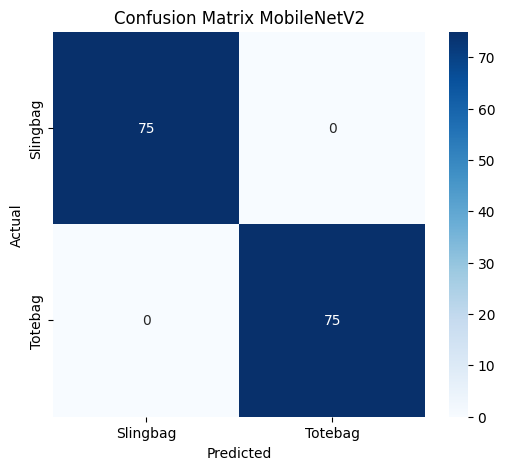

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix MobileNetV2"
)

plt.show()

# Model Comparison

Notebook ini bertujuan untuk membandingkan performa model HOG+SVM dan MobileNetV2 berdasarkan hasil evaluasi yang diperoleh. Perbandingan dilakukan untuk mengetahui efektivitas pendekatan Machine Learning dan Deep Learning dalam tugas klasifikasi citra Slingbag dan Totebag.

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

In [110]:
comparison_df = pd.DataFrame({
    "Model": [
        "HOG + SVM (RBF)",
        "MobileNetV2"
    ],
    "Accuracy": [
        97.33,
        100.00
    ]
})

comparison_df

,Model,Accuracy
0,HOG + SVM (RBF),97.33
1,MobileNetV2,100.00


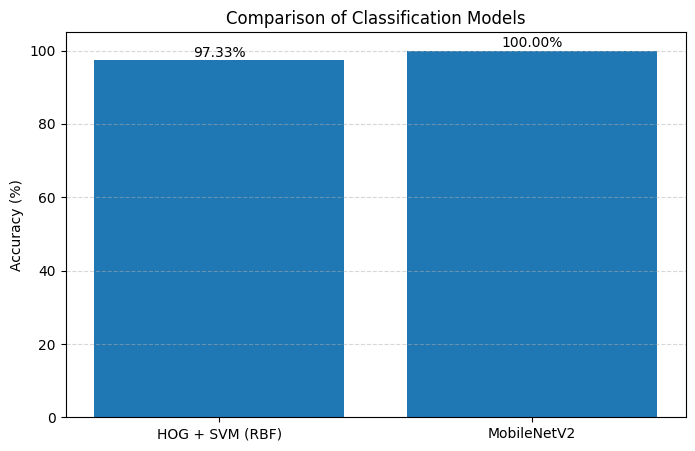

In [111]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.ylabel("Accuracy (%)")

plt.title(
    "Comparison of Classification Models"
)

plt.ylim(0,105)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.2f}%",
        ha="center"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.show()

In [112]:
best_model = comparison_df.loc[
    comparison_df["Accuracy"].idxmax()
]

print(
    f"Best Model : {best_model['Model']}"
)

print(
    f"Accuracy   : {best_model['Accuracy']:.2f}%"
)

Best Model : MobileNetV2
Accuracy   : 100.00%


# Demo Prediction

Notebook ini digunakan untuk melakukan demonstrasi prediksi menggunakan model terbaik yang diperoleh dari hasil eksperimen. Pengguna dapat mengunggah citra Slingbag atau Totebag, kemudian sistem akan menampilkan hasil klasifikasi beserta tingkat keyakinan prediksi model.

In [113]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from google.colab import files

In [114]:
MODEL_PATH = (
    "/content/drive/MyDrive/Dataset ML/"
    "mobilenetv2_best.keras"
)

model = tf.keras.models.load_model(
    MODEL_PATH
)

print("Model loaded successfully")

Model loaded successfully


In [127]:
uploaded = files.upload()

Saving a0431318b1b8b42367c967bff39b2fed.jpg_720x720q80.jpg to a0431318b1b8b42367c967bff39b2fed.jpg_720x720q80.jpg


In [128]:
image_path = list(
    uploaded.keys()
)[0]

print(image_path)

a0431318b1b8b42367c967bff39b2fed.jpg_720x720q80.jpg


In [129]:
IMG_SIZE = (256, 256)

img = Image.open(
    image_path
).convert("RGB")

img_resized = img.resize(
    IMG_SIZE
)

img_array = np.array(
    img_resized
)

img_batch = np.expand_dims(
    img_array,
    axis=0
)

img_batch = (
    tf.keras.applications.mobilenet_v2
    .preprocess_input(img_batch)
)

In [132]:
prediction = model.predict(
    img_batch,
    verbose=0
)

score = prediction[0][0]

print(
    "Raw Prediction:",
    score
)

Raw Prediction: 0.6846819


In [133]:
if score < 0.5:

    label = "Slingbag"

    confidence = (
        1 - score
    ) * 100

else:

    label = "Totebag"

    confidence = (
        score
    ) * 100

print(
    f"Prediction : {label}"
)

print(
    f"Confidence : {confidence:.2f}%"
)

Prediction : Totebag
Confidence : 68.47%


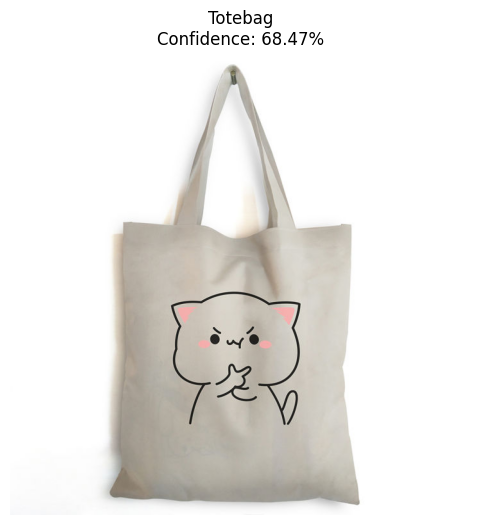

In [134]:
plt.figure(figsize=(6,6))

plt.imshow(img)

plt.axis("off")

plt.title(
    f"{label}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.show()